# Modelos de boosting avanzados

A partir del algoritmo de gradient boosting, han surgido nuevos algoritmos que mejoran su desempeño.

Se van a presentar los 3 algoritmos de boosting más populares hoy en día: XGBoost, LightGBM y CatBoost.

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship','race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
    na_values=' ?'
    )

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# XGBoost

XGBoost mantiene la misma idea central que Gradient Boosting (entrenar árboles secuenciales sobre los residuos/gradientes), pero introduce **tres mejoras clave** que lo hacen más rápido, robusto y preciso.

### 1. Regularización explícita (control de sobreajuste)

Mientras que Gradient Boosting clásico solo controla la complejidad con la tasa de aprendizaje η y el número de árboles, XGBoost añade **términos de regularización** en la función objetivo de cada árbol:

- $\gamma$ (gamma) = penalización por añadir una hoja extra
- $\lambda$ (lambda) = regularización L2 sobre los pesos de las hojas

Así, XGBoost prefiere árboles **más simples** (menos hojas) con **valores pequeños** en las hojas. Esto reduce drásticamente el sobreajuste.

### 2. Aproximación del gradiente de segundo orden (Newton boosting)

Gradient Boosting clásico usa solo el **gradiente de primer orden** (derivada) de la pérdida. XGBoost usa también la **segunda derivada** o **Hessiano**. Esto hace que converja más rápido y permite usar funciones de pérdida más complejas (incluyendo las que no son diferenciables en primer orden).

### 3. Algoritmo de búsqueda de división optimizado

En GB, para cada división candidata, hay que recorrer todos los valores de cada característica. En XGBoost se usan **cuantiles ponderados**: En lugar de probar cada punto, XGBoost agrupa los datos en bins basándose en cuantiles, pero cada bin no tiene el mismo número de observaciones, sino que tiene la misma suma de pesos (hessianos). Estos pesos representan el error o incertidumbre de cada observación.

Adicionalmente, las versiones más recientes de XGBoost implementan las siguientes funciones:

- **Manejo automático de valores faltantes**: Aprende la dirección óptima (izquierda o derecha) para valores nulos.
- **Paralelización**: Las divisiones se evalúan en paralelo (aunque los árboles sean secuenciales, las búsquedas de división se paralelizan).
- Soporte nativo de variables categóricas: XGBoost procesa estas variables basándose en un algoritmo de **partición óptima**.

Este algoritmo primero mapea cada categoría única a un valor entero. Luego, agrupa estas categorías en bins, similar a como lo hace con las variables numéricas. Luego el algoritmo busca repartir las categorías en dos grupos para maximizar la ganancia de información. Para evitar probar todas las combinaciones posibles de categorías, XGBoost las ordena basándose en sus estadísticas de gradiente (la relación entre la categoría y el error que estamos corrigiendo). Una vez ordenadas, el problema se vuelve similar al de una variable numérica, permitiendo encontrar el corte óptimo de manera mucho más rápida.

Este algoritmo tiene varias ventajas sobre el One-Hot Encoding:

- Mientras One-Hot Encoding crea matrices dispersas (sparse) con muchísimos ceros. El soporte nativo mantiene la matriz densa y pequeña.
- Relaciones semánticas: El tratamiento nativo suele capturar mejor la relación entre categorías que tienen comportamientos similares frente a la variable objetivo, algo que se pierde cuando se "aplanan" las categorías en columnas independientes.- Velocidad: Al reducir la dimensionalidad, el entrenamiento es significativamente más rápido en datasets con variables de alta cardinalidad (muchas categorías únicas).

Para usar XGBoost, es necesario instalar una librería.

Para que funcione el procesamiento nativo de variables categóricas, es necesario convertir estas variables de tipo **object** (o **str**) a tipo **category**:

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop('income', axis=1)
y = df['income']

categorical_features = X.select_dtypes(include='object').columns.to_list()
X[categorical_features] = X[categorical_features].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

Se va a entrenar un modelo sin sintonizar hiperparámetros:

In [4]:
from xgboost import XGBClassifier

model = XGBClassifier(
    grow_policy='lossguide',
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=20,
    )

model.fit(X_train,
          y_train,
          eval_set=[(X_test, y_test)],
          verbose=False
          )

print(f'La exactitud de este modelo con los datos de entrenamiento es: {model.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {model.score(X_test, y_test):.3f}')


La exactitud de este modelo con los datos de entrenamiento es: 0.887
La exactitud de este modelo con los datos de prueba es: 0.870


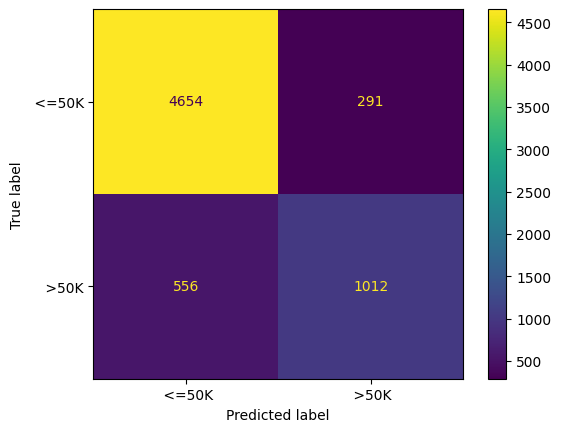

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=le.classes_);

In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test), target_names=le.classes_))

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      4945
        >50K       0.78      0.65      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.87      0.87      0.87      6513



Aún sin sintonizar el resultado es muy bueno.

En XGBoost existen muchos hiperparámetros que se pueden ajustar para optimizar el rendimiento del modelo. La elección de los hiperparámetros más adecuados dependerá del conjunto de datos específico y la tarea que se esté realizando. Sin embargo, algunos de los hiperparámetros más comunes que se ajustan en XGBoost incluyen:

* **`learning_rate`:** Controla la magnitud de los ajustes realizados en el modelo en cada iteración. Un valor de aprendizaje bajo puede conducir a un entrenamiento más lento, mientras que un valor alto puede conducir a un sobreajuste. En general, se recomienda comenzar con un valor de aprendizaje bajo y aumentarlo gradualmente si es necesario.
* **`n_estimators`:** Determina el número de árboles de decisión que se agregarán al modelo. Un mayor número de árboles puede mejorar la precisión, pero también puede aumentar el riesgo de sobreajuste. Se recomienda comenzar con un número bajo de árboles y aumentar gradualmente si es necesario.
* **`max_depth`:** Controla la profundidad máxima de los árboles de decisión. Árboles más profundos pueden capturar patrones más complejos, pero también pueden aumentar el riesgo de sobreajuste. Un valor típico para este hiperparámetro es de 3 a 10.
* **`gamma`:** Regula la regularización L2 de los árboles de decisión. Un valor más alto de gamma ayuda a evitar el sobreajuste al penalizar árboles más complejos. Un valor típico para este hiperparámetro es de 0 a 1.
* **`min_child_weight`:** Controla el peso mínimo que debe tener una hoja en un árbol de decisión. Un valor más alto ayuda a evitar que el modelo aprenda de patrones irrelevantes o con pocos datos. Un valor típico para este hiperparámetro es de 5 a 10.
* **`early_stopping_rounds`:** Controla cuando detener las iteraciones del modelo dependiendo de si el score de validación mejora o no.
* **`colsample_bytree`:** Controla la proporción de características que se seleccionan aleatoriamente en cada iteración para entrenar un árbol de decisión. Un valor más alto puede conducir a la exploración de un espacio de características más diverso, pero también puede aumentar el tiempo de entrenamiento. Un valor típico para este hiperparámetro es de 0.5 a 1.0.
* **`reg_alpha`:** Regula la regularización L1 de las características. Un valor más alto de reg_alpha ayuda a evitar el sobreajuste al penalizar características con valores grandes. Un valor típico para este hiperparámetro es de 0 a 1.0.

In [7]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV

X_train_cv, X_val, y_train_cv, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1,
    stratify=y_train
    )

dist = {'n_estimators':randint(1,500),
        'max_depth':randint(3,10),
        'learning_rate':loguniform(0.001,0.3),
        'subsample':uniform(0.5,0.5),
        'colsample_bytree':uniform(0.5,0.5),
        'min_child_weight':randint(5,10),
        'gamma':uniform(0,5),
        'reg_alpha':loguniform(1e-3,10),
        'reg_lambda':loguniform(1e-3,10),
        'scale_pos_weight':uniform(1,10),
        'max_delta_step':randint(0,10),
        }

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    random_state=1,
    n_iter=20,
    scoring='f1_weighted'
    )

random_search.fit(
    X_train_cv,
    y_train_cv,
    eval_set=[(X_val, y_val)],
    verbose=False
    )

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.862 with parameters: {'colsample_bytree': np.float64(0.958221851547185), 'gamma': np.float64(2.310762564276142), 'learning_rate': np.float64(0.002126385865951228), 'max_delta_step': 6, 'max_depth': 9, 'min_child_weight': 6, 'n_estimators': 459, 'reg_alpha': np.float64(0.0069294065087317286), 'reg_lambda': np.float64(1.0257043915608959), 'scale_pos_weight': np.float64(1.6653648135411494), 'subsample': np.float64(0.6301575492892705)}
Train score: 0.868
Test score: 0.859


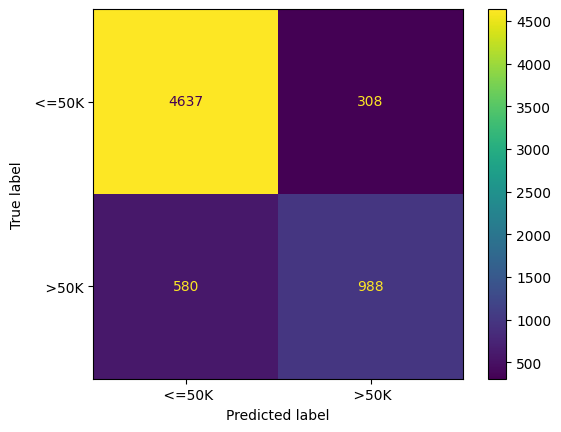

In [8]:
ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [9]:
print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      4945
        >50K       0.76      0.63      0.69      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.78      0.80      6513
weighted avg       0.86      0.86      0.86      6513



Este modelo también da información acerca de la importancia relativa de cada característica:

In [10]:
xgb_features = pd.DataFrame({'Feature': random_search.best_estimator_.feature_names_in_,
                             'Importance': random_search.best_estimator_.feature_importances_})
xgb_features.sort_values('Importance', ascending=False)

,Feature,Importance
7,relationship,0.472274
5,marital-status,0.220164
10,capital-gain,0.103091
6,occupation,0.044475
4,education-num,0.041632
3,education,0.040257
11,capital-loss,0.021507
0,age,0.012474
12,hours-per-week,0.012073
1,workclass,0.007962


# LightGBM

**Problema que resuelve**: XGBoost, aunque optimizado, sigue siendo lento en datasets **muy grandes** (millones de filas o miles de características) porque su búsqueda de división requiere ordenar todos los valores.

### Mejora 1: Histogramas en lugar de búsqueda exacta

**XGBoost**: Para cada característica, ordena los valores y prueba todos los puntos de división posibles (o cuantiles).  
**LightGBM**: Discretiza cada característica en **bins** (ej. 255 bins) y construye un histograma. La mejor división se busca en los límites de los bins, no en los valores exactos. Así, la complejidad pasa de $O(\text{datos} \times \text{features})$ a $O(\text{bins} \times \text{features})$. A manera de ejemplo, con 10 millones de filas y 256 bins, LightGBM sería en teoría 40000 veces más rápido que XGBoost.

### Mejora 2: Crecimiento por hojas (leaf-wise) vs nivel (level-wise)

**XGBoost / GB clásico**: Crecimiento balanceado por niveles. Primero divide la raíz, luego todas las hojas del nivel 1, luego todas las del nivel 2, etc.

**LightGBM**: Crecimiento por **hoja con mayor ganancia**. En cada paso, solo expande la hoja que más reduce la pérdida.

```
Level-wise (XGBoost):          Leaf-wise (LightGBM):
       N0                               N0
      /  \                             /  \
     N1   N2                         N1   N2
    / \  / \                             / \
   N3 N4 N5 N6                           N3 N4
                                              \
                                               N5
```

- **Ventaja**: Árboles más profundos y asimétricos, menor error con el mismo número de nodos.
- **Riesgo**: Puede sobreajustar si no se controla. LightGBM usa parámetros como `num_leaves` y `min_child_samples` para regularlo.

### Mejora 3: Muestreo de gradientes (GOSS)

Gradient-based One-Side Sampling: Solo usa las muestras con **gradientes más grandes** (las que están peor clasificadas) para entrenar cada árbol.

- **Procedimiento**:
  1. Ordenar muestras por valor absoluto del gradiente.
  2. Tomar **todas** las muestras con gradiente alto (top a%).
  3. Tomar **una muestra aleatoria** de las de gradiente bajo (top b%).
  4. Las de gradiente bajo se multiplican por un factor para corregir el sesgo.

- **Ventaja**: Reduce drásticamente el número de muestras por árbol (ej. usa solo 30% de los datos sin perder precisión).

### Mejora 4: Fusión de características dispersas (EFB)

*Exclusive Feature Bundling* agrupa características que **nunca son cero simultáneamente** en una sola característica compuesta.

- **Ejemplo**: Una característica "tiene gato" y otra "tiene perro". En un dataset de mascotas, nunca aparecen juntas. LightGBM las fusiona en una sola característica "tiene mascota" con codificación especial.
- **Ventaja**: Reduce la dimensionalidad para datos dispersos (ej. one-hot encoding).

Este algoritmo también tiene su propia libreria:



Se va a entrenar un modelo sin sintonizar:

In [11]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    objective='binary',
    verbose=0,
    )

lgb_model.fit(
    X_train_cv,
    y_train_cv,
    eval_set=[(X_val, y_val)],
    eval_metric='logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=10)],
    )

print(f'La exactitud de este modelo con los datos de entrenamiento es: {lgb_model.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {lgb_model.score(X_test, y_test):.3f}')

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[92]	valid_0's binary_logloss: 0.288083
La exactitud de este modelo con los datos de entrenamiento es: 0.890
La exactitud de este modelo con los datos de prueba es: 0.872


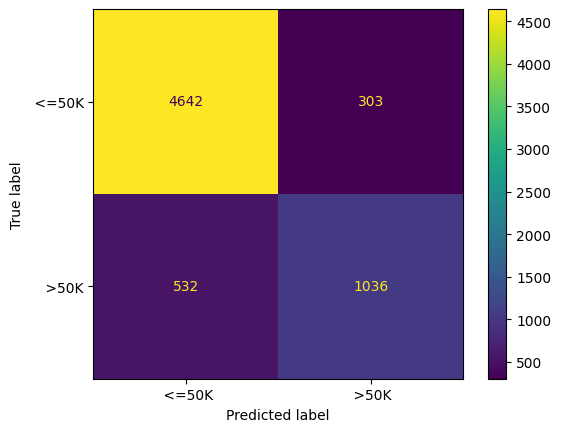

In [12]:
ConfusionMatrixDisplay.from_estimator(
    lgb_model,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [13]:
print(classification_report(
    y_test,
    lgb_model.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.77      0.66      0.71      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.80      0.82      6513
weighted avg       0.87      0.87      0.87      6513



LightGBM tiene más de 100 hiperparámetros que se pueden ajustar. La lista completa se puede consultar aquí: https://github.com/microsoft/LightGBM/blob/master/docs/Parameters.rst.

Además de los que son comunes a los otros algoritmos de ensamble, algunos muy utilzados son:

- `num_boost_round`: Número de iteraciones de refuerzo, normalmente más de 100
- `num_leaves`: número de hojas en el árbol completo, por defecto: 31.
- `min_gain_to_split`: Este parámetro describe la ganancia mínima para realizar una división. Puede utilizarse para controlar el número de divisiones útiles en el árbol.
- `max_cat_group`: Cuando el número de categorías es grande, es fácil sobreajustarse, así que LightGBM las fusiona en grupos y encuentra los puntos de división en los límites del grupo, por defecto 64.

In [14]:
param_distributions = {
    'num_leaves': randint(20, 150),
    'max_depth': randint(3, 15),
    'learning_rate': loguniform(0.01, 0.3),
    'n_estimators': randint(50, 500),
    'min_child_samples': randint(2, 50),
    'subsample': uniform(0.5, 0.5),  # de 0.5 a 1.0
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': loguniform(1e-3, 10),
    'reg_lambda': loguniform(1e-3, 10),
    'scale_pos_weight': uniform(1, 10)  # Solo si hay desbalance
}

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_weighted',
    random_state=1
    )

random_search.fit(
    X_train_cv,
    y_train_cv,
    categorical_feature=categorical_features,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10)],
    )

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

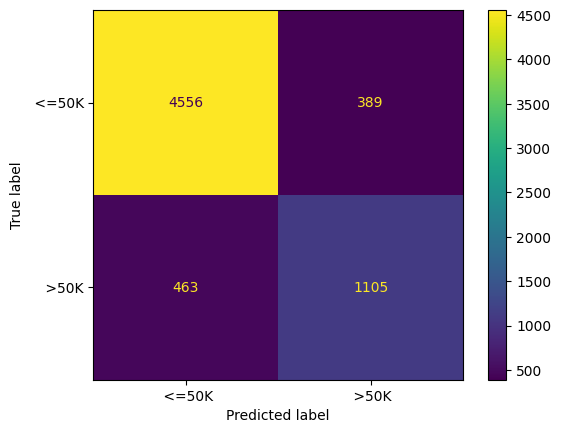

In [15]:
ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [16]:
print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.91      4945
        >50K       0.74      0.70      0.72      1568

    accuracy                           0.87      6513
   macro avg       0.82      0.81      0.82      6513
weighted avg       0.87      0.87      0.87      6513



Este modelo también da información acerca de la importancia relativa de cada característica:

In [17]:
lgb_features = pd.DataFrame({
    'Feature':random_search.best_estimator_.feature_name_,
    'Importance': random_search.best_estimator_.feature_importances_
    })

lgb_features.sort_values('Importance', ascending=False)

,Feature,Importance
2,fnlwgt,2592
0,age,2566
12,hours-per-week,1413
4,education-num,1073
10,capital-gain,1015
11,capital-loss,957
6,occupation,488
9,sex,301
1,workclass,274
3,education,231


# CatBoost

**Problema que resuelve**: XGBoost y LightGBM requieren **codificar** las variables categóricas (one-hot, ordinal), lo que:
- Aumenta la dimensionalidad.
- Puede causar **target leakage** (fugas de la variable objetivo en la codificación).

CatBoost (Categorical Boosting) fue creado por Yandex para manejar **datos puramente categóricos** de forma nativa.

### Mejora 1: Estadísticas target ordenadas (Ordered Target Statistics)

**Problema**: La forma ingenua de convertir una categórica a numérica es reemplazar cada categoría por la **media de la variable objetivo** en esa categoría. Pero esto genera **fuga de información** (la categoría "ve" el valor que intenta predecir).

**Solución de CatBoost**: Usa **permutaciones aleatorias** del orden de los datos. Así, para la muestra i, solo se usa muestras anteriores en la permutación para calcular la media de la categoría. Así no hay fuga del valor actual. Esto elimina el sobreajuste por target leakage.

### Mejora 2: Combinación de categorías (Feature combinations)

CatBoost automáticamente crea **nuevas características** combinando múltiples categóricas.

- **Ejemplo**: Si dos características son "ciudad" y "profesión", CatBoost prueba combinaciones como "ciudad:profesión" como nueva característica.
- **Ventaja**: Captura interacciones sin que el usuario las especifique.

### Mejora 3: Árboles simétricos (obligatorios en versiones iniciales)

CatBoost tradicionalmente usa **árboles balanceados y simétricos**: En cada nivel, la misma división se aplica a todas las hojas. Esto reduce el sobreajuste y permite predicciones muy rápidas.

```
Árbol simétrico (CatBoost):
        ¿x1 < 5?
       /        \
   ¿x2 < 3?    ¿x2 < 3?  ← misma condición en ambas ramas
    /    \      /    \
```

**Ventaja**: Predicción con aritmética de enteros (muy rápido en CPU).  
**Desventaja**: Menos expresivo que árboles asimétricos.

Al igual que con los modelos anteriores, también es necesario instalar una librería:

CatBoost soporta datos nulos de variables numéricas, pero no de variables categóricas.

In [18]:
df_na = df.dropna(subset=categorical_features)

X = df_na.drop('income', axis=1)
y = df_na['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

X_train_cv, X_val, y_train_cv, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1,
    stratify=y_train
    )


In [19]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    verbose=0,
)

cat_model.fit(
    X_train_cv,
    y_train_cv,
    cat_features=categorical_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=10,
    )

print(f'La exactitud de este modelo con los datos de entrenamiento es: {cat_model.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {cat_model.score(X_test, y_test):.3f}')

La exactitud de este modelo con los datos de entrenamiento es: 0.876
La exactitud de este modelo con los datos de prueba es: 0.873


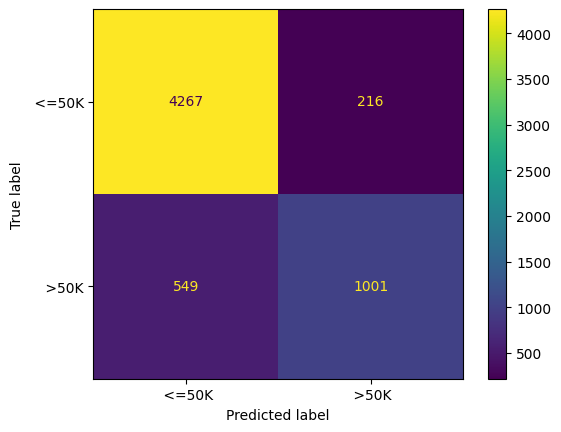

In [20]:
ConfusionMatrixDisplay.from_estimator(
    cat_model,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [21]:
print(classification_report(
    y_test,
    cat_model.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      4483
        >50K       0.82      0.65      0.72      1550

    accuracy                           0.87      6033
   macro avg       0.85      0.80      0.82      6033
weighted avg       0.87      0.87      0.87      6033



CatBoost ofrece una amplia gama de hiperparámetros que se pueden ajustar para optimizar el rendimiento del modelo. Algunos de los hiperparámetros más comunes que se ajustan en CatBoost incluyen:

**Hiperparámetros generales:**

* **`learning_rate`:** Controla la magnitud de los ajustes realizados en el modelo en cada iteración. Un valor de aprendizaje bajo puede conducir a un entrenamiento más lento, mientras que un valor alto puede conducir a un sobreajuste.
* **`n_estimators`:** Determina el número de árboles de decisión que se agregarán al modelo. Un mayor número de árboles puede mejorar la precisión, pero también puede aumentar el riesgo de sobreajuste.
* **`loss_function`:** Especifica la función de pérdida que se utiliza para evaluar el error del modelo. Las opciones comunes incluyen "LogLoss" para tareas de clasificación y "RMSE" para tareas de regresión.
* **`early_stopping_rounds`:** Detiene el entrenamiento si el error en el conjunto de validación no mejora durante un número específico de iteraciones. Esto ayuda a evitar el sobreajuste.

**Hiperparámetros para árboles de decisión:**

* **`max_depth`:** Controla la profundidad máxima de los árboles de decisión. Árboles más profundos pueden capturar patrones más complejos, pero también pueden aumentar el riesgo de sobreajuste.
* **`leaf_count`:** Determina el número mínimo de hojas en cada árbol de decisión. Un mayor número de hojas puede conducir a modelos más flexibles, pero también puede aumentar el riesgo de sobreajuste.
* **`cat_feature_mode`:** Especifica cómo se procesan las características categóricas. Las opciones comunes incluyen "OneHot" para codificar cada categoría como una variable binaria separada y "Summ" para sumar las estadísticas de las categorías.

**Hiperparámetros para la selección de características:**

* **`feature_selection_random_fraction`:** La proporción de características que se seleccionan aleatoriamente en cada iteración. Un valor más alto puede conducir a la exploración de un espacio de características más diverso, pero también puede aumentar el tiempo de entrenamiento.
* **`feature_selection_l2_leaf_reg`:** Regula la complejidad de los árboles de decisión penalizando las características con valores grandes. Un valor más alto puede ayudar a evitar el sobreajuste.


In [ ]:
param_distributions = {
    'iterations': randint(50, 1000),
    'depth': randint(4, 12),
    'learning_rate': loguniform(0.01, 0.3),
    'l2_leaf_reg': loguniform(1e-3, 10),
    'min_child_samples': randint(1, 50),
    'subsample': uniform(0.6, 0.4),
    'colsample_bylevel': uniform(0.6, 0.4),
    'border_count': randint(32, 255),
    'random_strength': loguniform(1e-3, 10),
}

random_search = RandomizedSearchCV(
    estimator=cat_model,
    n_iter=10,
    param_distributions=param_distributions,
    scoring='f1_weighted',
    random_state=1
    )

random_search.fit(
    X_train_cv,
    y_train_cv,
    cat_features=categorical_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=10
    )

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

Best validation score: 0.862 with parameters: {'border_count': 69, 'colsample_bylevel': np.float64(0.9988739243755475), 'depth': 4, 'iterations': 817, 'l2_leaf_reg': np.float64(0.0032546012860767224), 'learning_rate': np.float64(0.2990225766972874), 'min_child_samples': 1, 'random_strength': np.float64(0.0023407464805767528), 'subsample': np.float64(0.6745040845510684)}
Train score: 0.870
Test score: 0.865


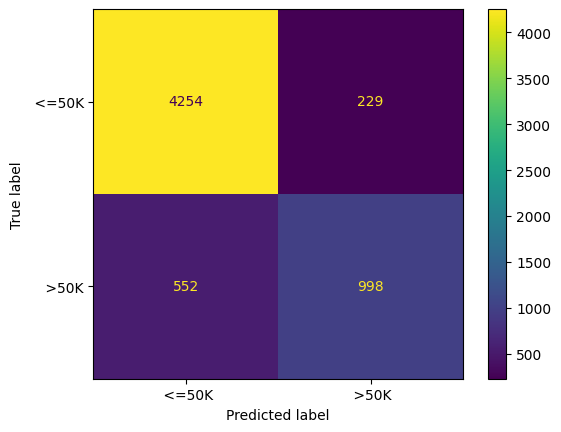

In [23]:
ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [24]:
print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      4483
        >50K       0.81      0.64      0.72      1550

    accuracy                           0.87      6033
   macro avg       0.85      0.80      0.82      6033
weighted avg       0.87      0.87      0.87      6033



El modelo entrega la importancia relativa de cada característica.

In [25]:
cat_features = pd.DataFrame({
    'Feature':random_search.best_estimator_.feature_names_,
    'Importance': random_search.best_estimator_.feature_importances_})
cat_features.sort_values('Importance', ascending=False)

,Feature,Importance
10,capital-gain,25.225553
7,relationship,17.764993
0,age,15.147578
12,hours-per-week,11.277014
11,capital-loss,10.948979
4,education-num,8.655648
6,occupation,5.164505
1,workclass,1.238812
2,fnlwgt,1.075209
13,native-country,0.863887
